<a href="https://colab.research.google.com/github/srikanth6964/IDENTIFICATION-OF-METHODOLOGY-USED-IN-REAL-ESTATE-PROPEETY-VALUATION/blob/main/Copy_of_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report,confusion_matrix
import warnings
import pickle
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

In [ ]:
dt=pd.read_csv('/content/drive/MyDrive/ dataset/real estate valuation data set.csv')

In [ ]:
dt.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
dt.dropna(inplace=True)

In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
dt.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [ ]:
x=dt.drop('Y house price of unit area',axis=1)
y=dt['Y house price of unit area']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
train_dt=x_train.join(y_train)
train_dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
192,193,2013.167,43.8,57.58945,7,24.96750,121.54069,42.7
234,235,2013.250,8.0,2216.61200,4,24.96007,121.51361,23.9
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
45,46,2013.083,36.6,488.81930,8,24.97015,121.54494,38.3
245,246,2013.417,7.5,639.61980,5,24.97258,121.54814,40.8
...,...,...,...,...,...,...,...,...
71,72,2013.083,35.5,640.73910,3,24.97563,121.53715,40.8
106,107,2013.083,17.2,189.51810,8,24.97707,121.54308,47.1
270,271,2013.333,10.8,252.58220,1,24.97460,121.53046,117.5
348,349,2012.833,4.6,259.66070,6,24.97585,121.54516,53.7


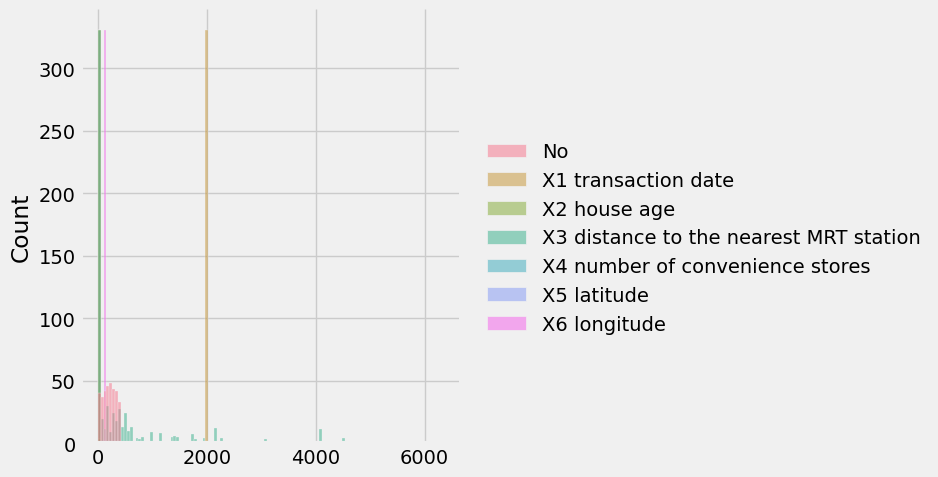

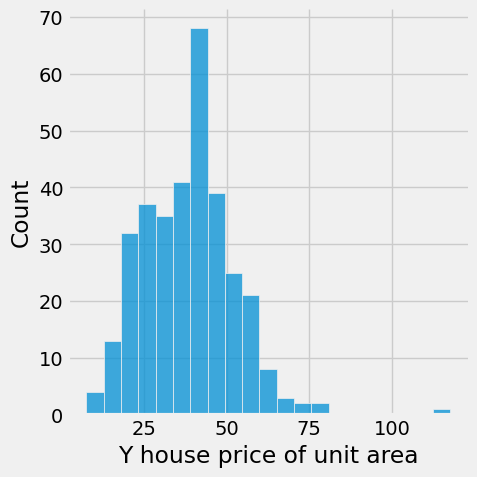

In [ ]:
sns.displot(x_train)
sns.displot(y_train)

In [ ]:
train_dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
192,193,2013.167,43.8,57.58945,7,24.96750,121.54069,42.7
234,235,2013.250,8.0,2216.61200,4,24.96007,121.51361,23.9
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
45,46,2013.083,36.6,488.81930,8,24.97015,121.54494,38.3
245,246,2013.417,7.5,639.61980,5,24.97258,121.54814,40.8
...,...,...,...,...,...,...,...,...
71,72,2013.083,35.5,640.73910,3,24.97563,121.53715,40.8
106,107,2013.083,17.2,189.51810,8,24.97707,121.54308,47.1
270,271,2013.333,10.8,252.58220,1,24.97460,121.53046,117.5
348,349,2012.833,4.6,259.66070,6,24.97585,121.54516,53.7


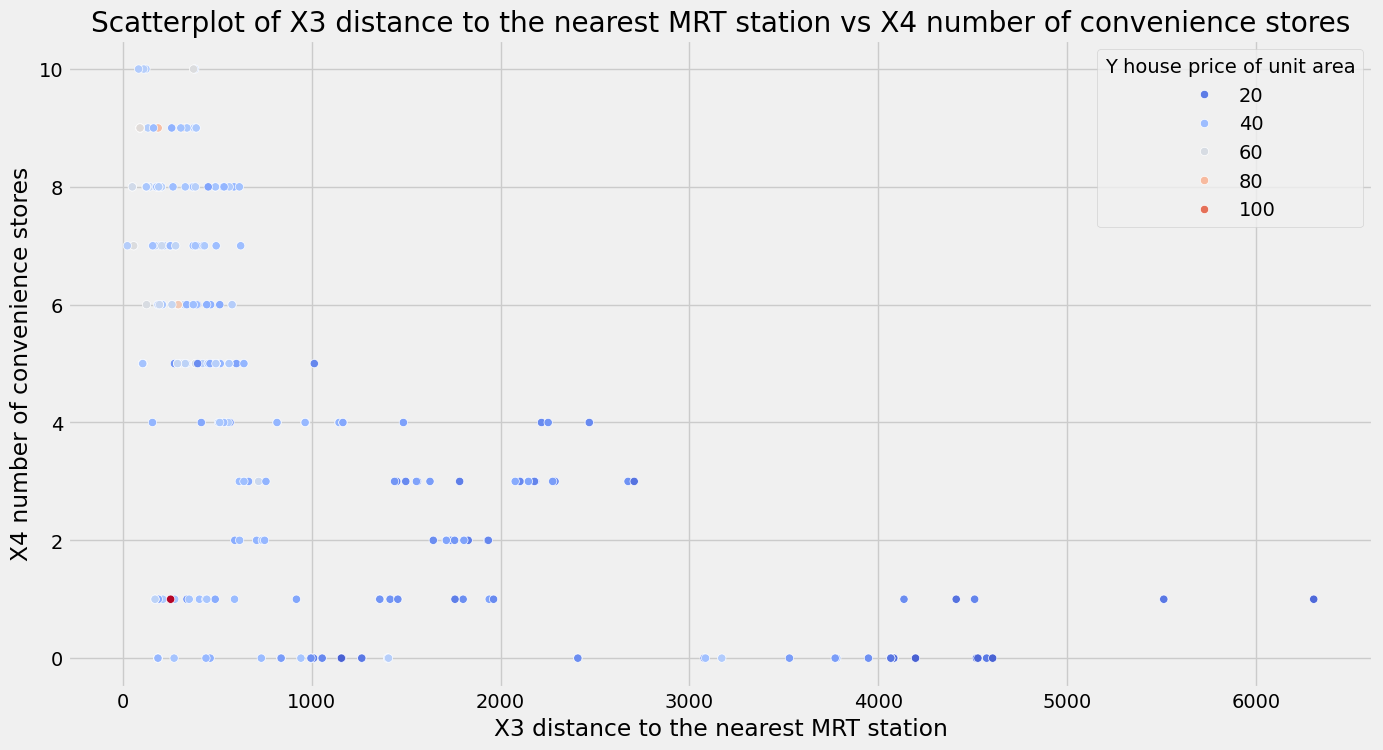

In [ ]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='X3 distance to the nearest MRT station',
y='X4 number of convenience stores',
                data=train_dt,
                hue='Y house price of unit area',palette="coolwarm")
plt.title('Scatterplot of X3 distance to the nearest MRT station vs X4 number of convenience stores')
plt.show()


In [ ]:
train_dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
192,193,2013.167,43.8,57.58945,7,24.96750,121.54069,42.7
234,235,2013.250,8.0,2216.61200,4,24.96007,121.51361,23.9
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
45,46,2013.083,36.6,488.81930,8,24.97015,121.54494,38.3
245,246,2013.417,7.5,639.61980,5,24.97258,121.54814,40.8
...,...,...,...,...,...,...,...,...
71,72,2013.083,35.5,640.73910,3,24.97563,121.53715,40.8
106,107,2013.083,17.2,189.51810,8,24.97707,121.54308,47.1
270,271,2013.333,10.8,252.58220,1,24.97460,121.53046,117.5
348,349,2012.833,4.6,259.66070,6,24.97585,121.54516,53.7


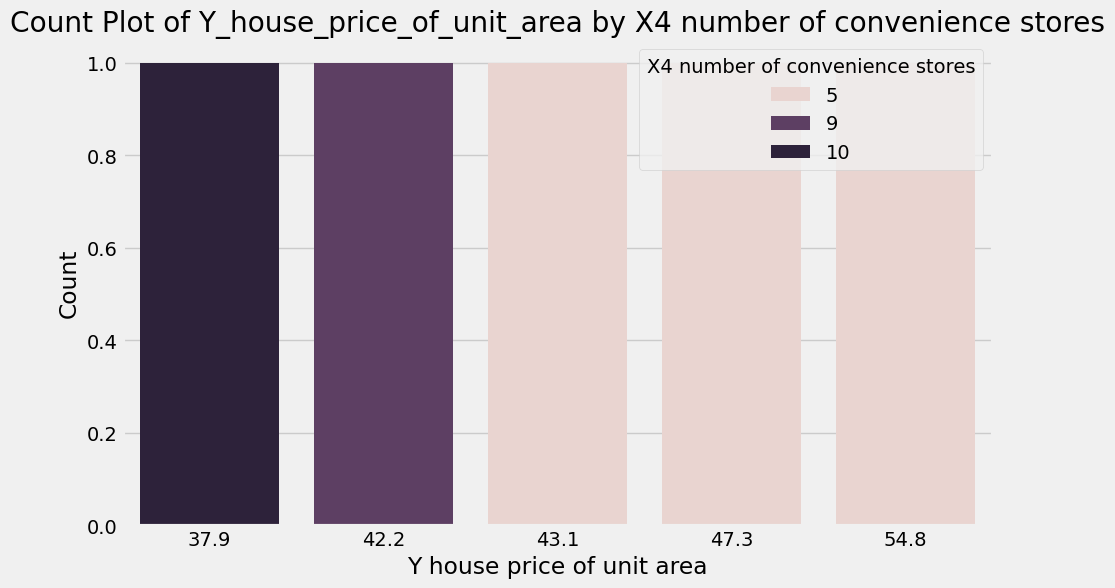

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
data = {
    "X1 transaction date": [2012.917, 2012.917, 2013.583, 2013.500, 2012.833],
    "X2 house age": [32.0, 19.5, 13.3, 13.3, 5.0],
    "X3 distance to the nearest MRT station": [84.87882, 306.59470, 561.98450, 561.98450, 390.56840],
    "X4 number of convenience stores": [10, 9, 5, 5, 5],
    "X5 latitude": [24.98298, 24.98034, 24.98746, 24.98746, 24.97937],
    "X6 longitude": [121.54024, 121.53951, 121.54391, 121.54391, 121.54245],
    "Y_house_price_of_unit_area": [37.9, 42.2, 47.3, 54.8, 43.1]
}
dt = pd.DataFrame(data)
plt.figure(figsize=(10, 6))
sns.countplot(x='Y_house_price_of_unit_area', hue='X4 number of convenience stores', data=dt)
plt.title('Count Plot of Y_house_price_of_unit_area by X4 number of convenience stores')
plt.xlabel('Y house price of unit area')
plt.ylabel('Count')
plt.legend(title='X4 number of convenience stores')
plt.show()


In [ ]:
dt.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y_house_price_of_unit_area
count,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000
mean,2013.150000,16.620000,381.202184,6.80000,24.983522,121.542004,45.06000
std,0.360228,10.023822,199.264918,2.48998,0.003830,0.002049,6.38694
min,2012.833000,5.000000,84.878820,5.00000,24.979370,121.539510,37.90000
25%,2012.917000,13.300000,306.594700,5.00000,24.980340,121.540240,42.20000
50%,2012.917000,13.300000,390.568400,5.00000,24.982980,121.542450,43.10000
75%,2013.500000,19.500000,561.984500,9.00000,24.987460,121.543910,47.30000
max,2013.583000,32.000000,561.984500,10.00000,24.987460,121.543910,54.80000


In [ ]:
dt.isnull().any()

X1 transaction date                       False
X2 house age                              False
X3 distance to the nearest MRT station    False
X4 number of convenience stores           False
X5 latitude                               False
X6 longitude                              False
Y_house_price_of_unit_area                False
dtype: bool

outliers in the column 'X1_transaction_date':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Column  
0              

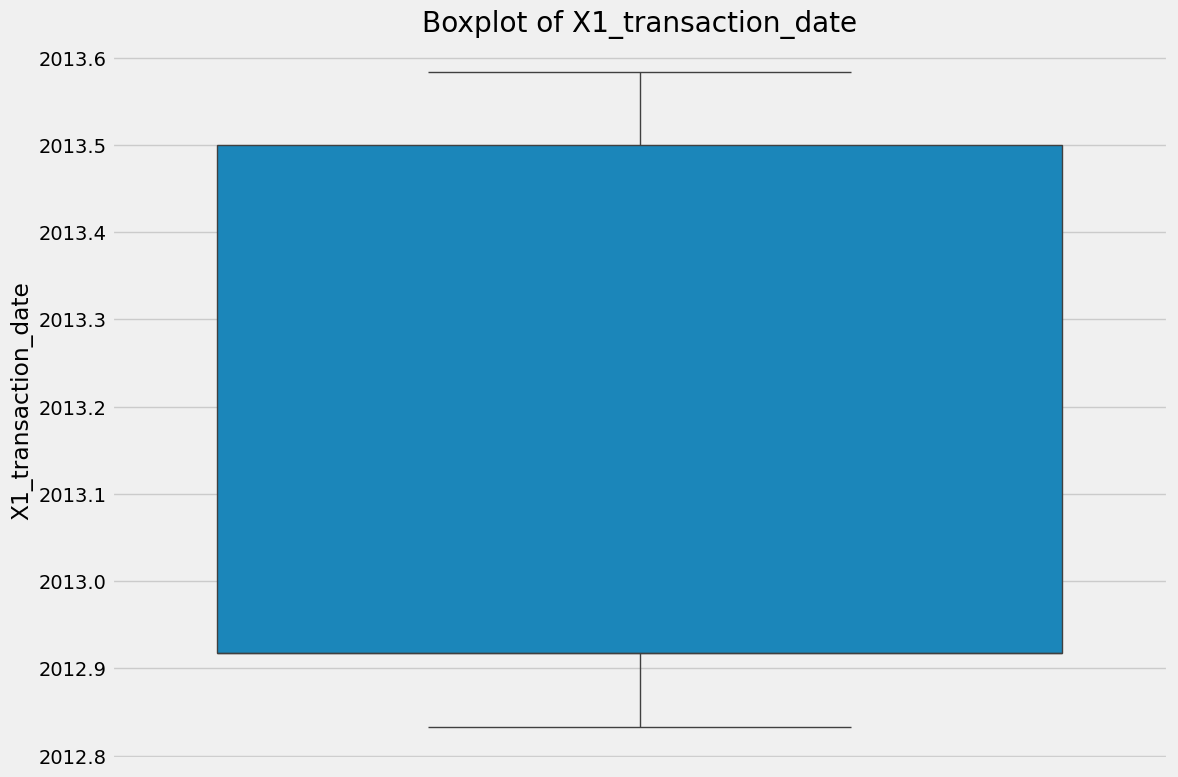

outliers in the column 'X2_house_age':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Column  
0                     

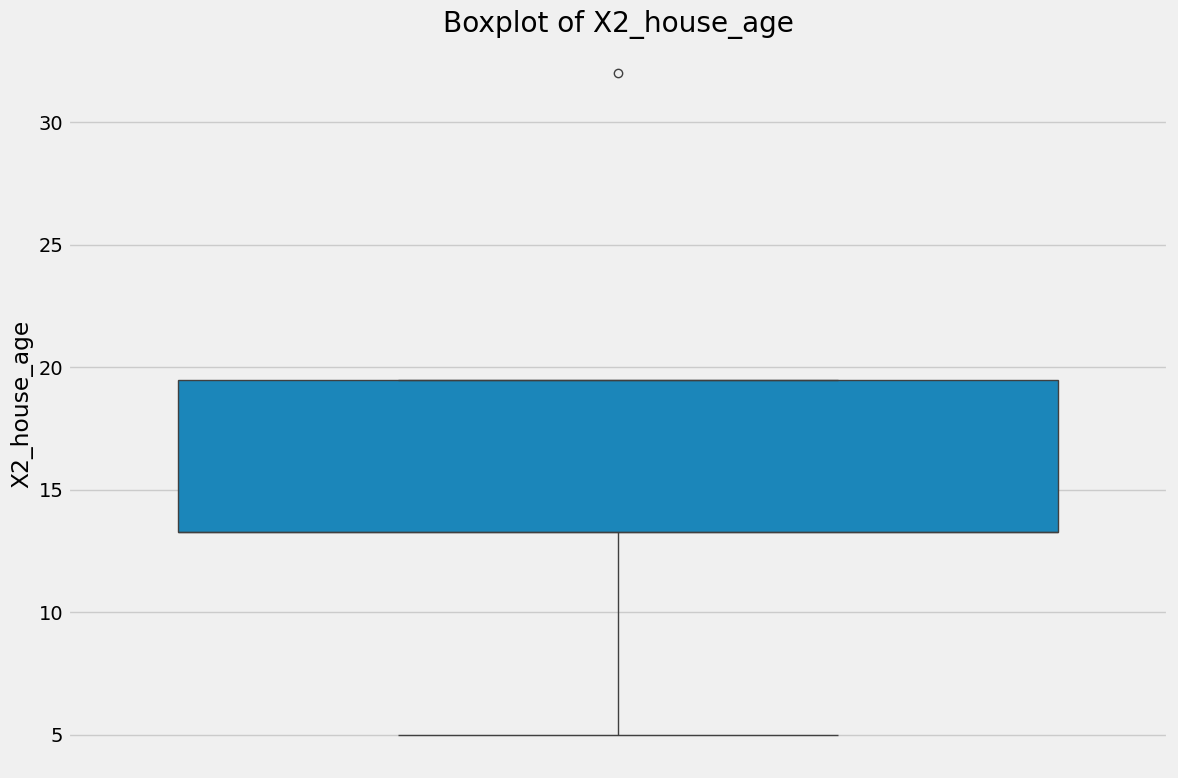

outliers in the column 'X3_distance_to_the_nearest_MRT_station':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Colum

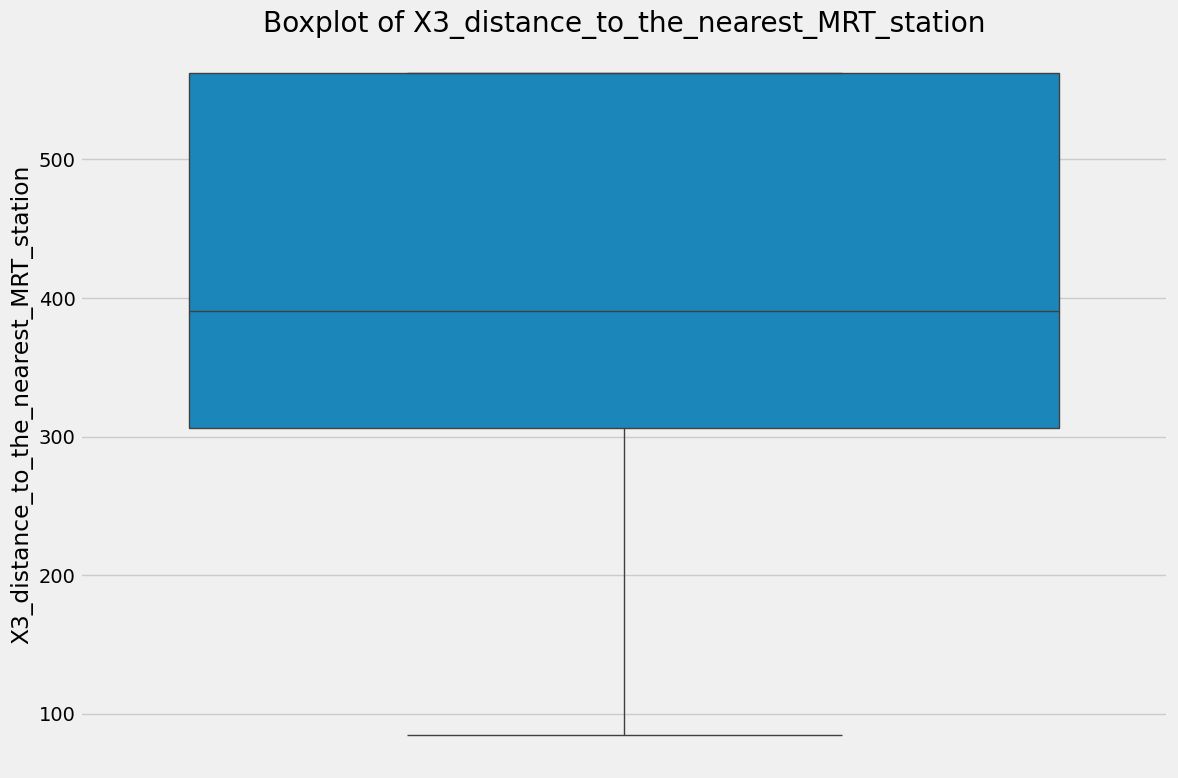

outliers in the column 'X4_number_of_convenience_stores':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Column  
0  

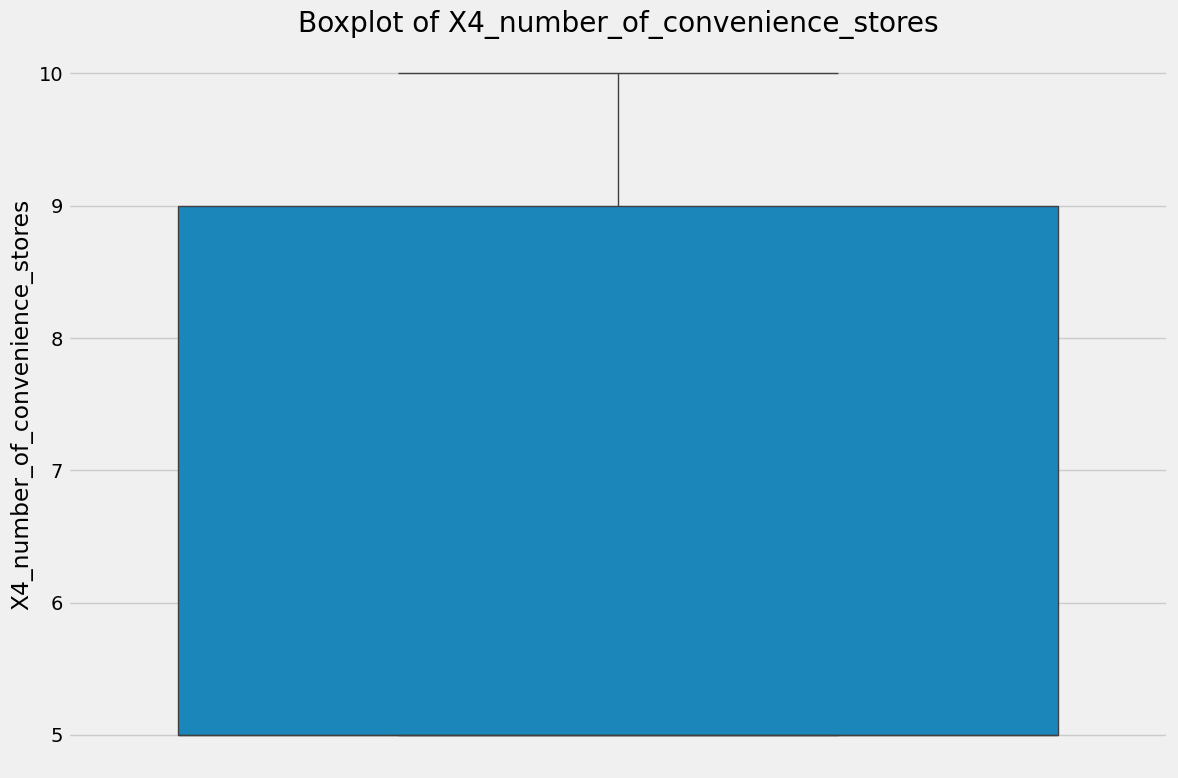

outliers in the column 'X5_latitude':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Column  
0                      

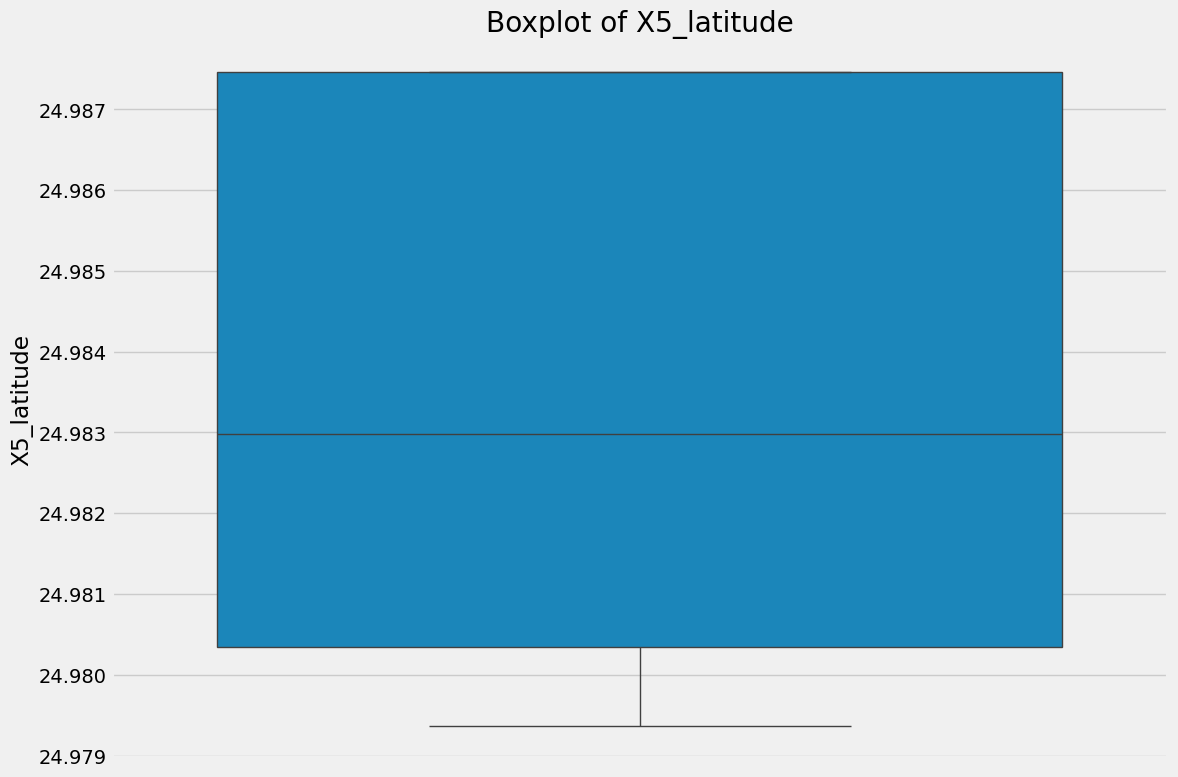

outliers in the column 'X6_longitude':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Column  
0                     

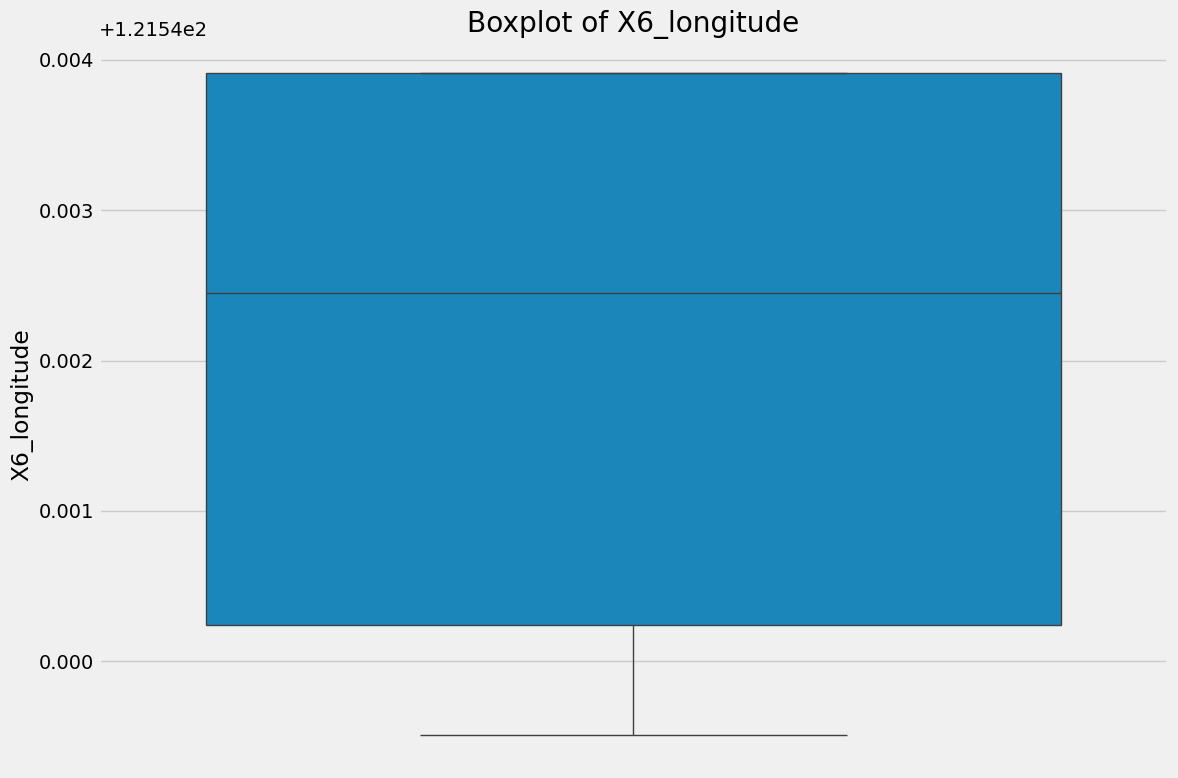

outliers in the column 'Y_house_price_of_unit_area':
All Outliers:
   X1_transaction_date  X2_house_age  X3_distance_to_the_nearest_MRT_station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4_number_of_convenience_stores  X5_latitude  X6_longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y_house_price_of_unit_area       Outlier_Column  
0       

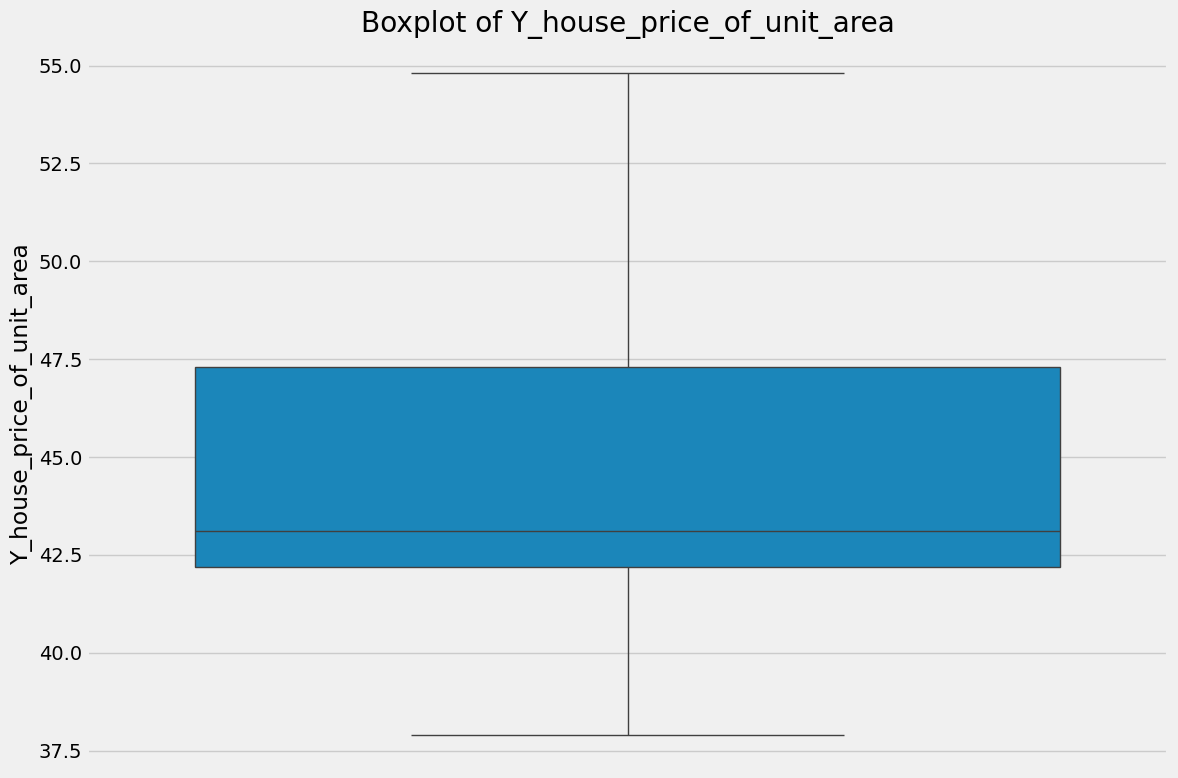

In [ ]:
dt.columns = dt.columns.str.replace(' ', '_')
column_to_check=['X1_transaction_date','X2_house_age','X3_distance_to_the_nearest_MRT_station','X4_number_of_convenience_stores','X5_latitude','X6_longitude','Y_house_price_of_unit_area']
outliers_dt=pd.DataFrame()
for column_name in column_to_check:
  Q1=dt['X3_distance_to_the_nearest_MRT_station'].quantile(0.05)
  Q3=dt['X3_distance_to_the_nearest_MRT_station'].quantile(0.95)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
  column_outliers=dt[(dt[column_name]<lower_limit)|(dt[column_name]>upper_limit)] # Now this line should work without error.
  column_outliers['Outlier_Column']=column_name
  outliers_dt=pd.concat([outliers_dt,column_outliers])
  outliers_dt.reset_index(drop=True,inplace=True)
  print("outliers in the column '{}':".format(column_name))
  print("All Outliers:")
  print(outliers_dt)
  plt.figure(figsize=(12,8))
  sns.boxplot(dt[column_name])
  plt.title('Boxplot of {}'.format(column_name))
  plt.tight_layout()
  plt.show()

In [ ]:
data = {
    "X1 transaction date": [2012.917, 2012.917, 2013.583, 2013.500, 2012.833],
    "X2 house_age": [32.0, 19.5, 13.3, 13.3, 5.0],
    "X3 distance to the nearest MRT station": [84.87882, 306.59470, 561.98450, 561.98450, 390.56840],
    "X4 number of convenience stores": [10, 9, 5, 5, 5],
    "X5 latitude": [24.98298, 24.98034, 24.98746, 24.98746, 24.97937],
    "X6 longitude": [121.54024, 121.53951, 121.54391, 121.54391, 121.54245],
    "Y house price of unit area": [37.9, 42.2, 47.3, 54.8, 43.1]
}
dt = pd.DataFrame(data)

# Define a function to remove outliers based on IQR
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Remove outliers
dt_no_outliers = remove_outliers_iqr(dt)

print("Original dataset size:", dt.shape)
print("Dataset size after removing outliers:", dt_no_outliers.shape)
print("Number of rows removed:", dt.shape[0] - dt_no_outliers.shape[0])

Original dataset size: (5, 7)
Dataset size after removing outliers: (4, 7)
Number of rows removed: 1


<Axes: xlabel='X3 distance to the nearest MRT station'>

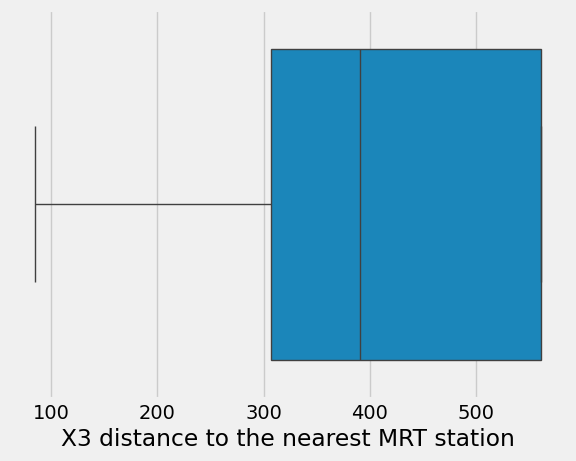

In [ ]:
sns.boxplot(data=dt,x='X3 distance to the nearest MRT station')

<Axes: xlabel='X4 number of convenience stores'>

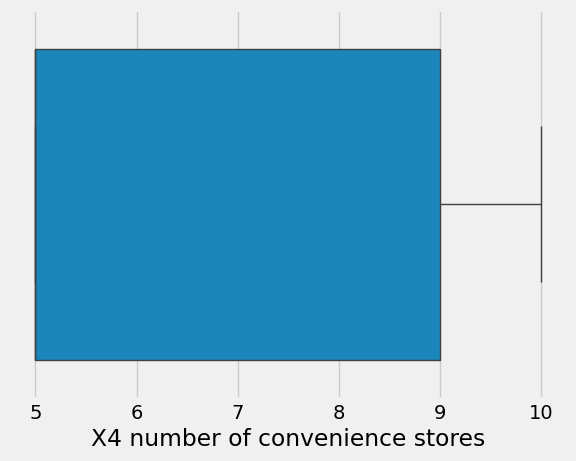

In [ ]:
sns.boxplot(data=dt,x='X4 number of convenience stores')

<Axes: xlabel='X5 latitude'>

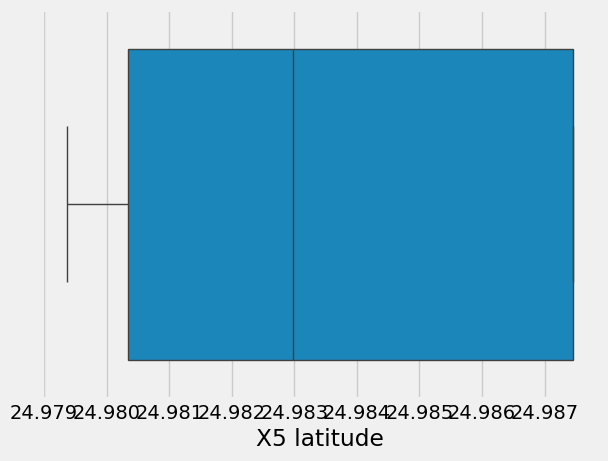

In [ ]:
sns.boxplot(data=dt,x='X5 latitude')

<Axes: xlabel='X6 longitude'>

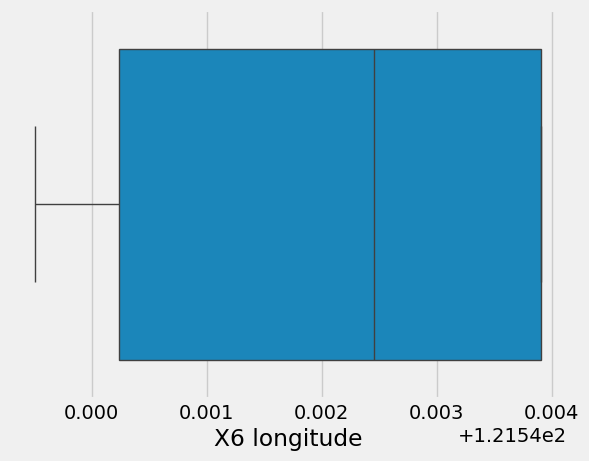

In [ ]:
sns.boxplot(data=dt,x='X6 longitude')

<Axes: xlabel='Y house price of unit area'>

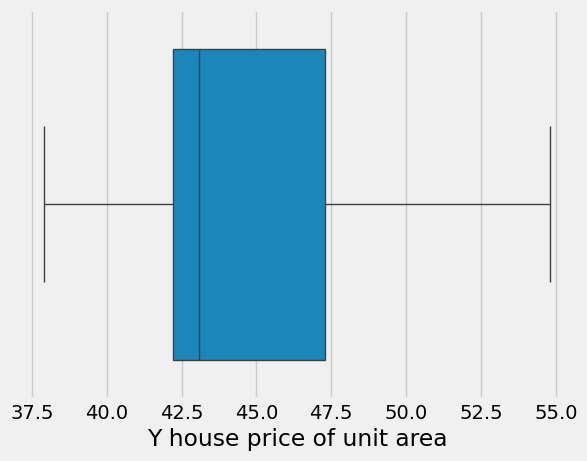

In [ ]:
sns.boxplot(data=dt,x='Y house price of unit area')

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
train_dt=x_train.join(y_train)
train_dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
192,193,2013.167,43.8,57.58945,7,24.96750,121.54069,42.7
234,235,2013.250,8.0,2216.61200,4,24.96007,121.51361,23.9
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
45,46,2013.083,36.6,488.81930,8,24.97015,121.54494,38.3
245,246,2013.417,7.5,639.61980,5,24.97258,121.54814,40.8
...,...,...,...,...,...,...,...,...
71,72,2013.083,35.5,640.73910,3,24.97563,121.53715,40.8
106,107,2013.083,17.2,189.51810,8,24.97707,121.54308,47.1
270,271,2013.333,10.8,252.58220,1,24.97460,121.53046,117.5
348,349,2012.833,4.6,259.66070,6,24.97585,121.54516,53.7


In [ ]:
X=dt.drop('Y house price of unit area',axis=1)
Y=dt['Y house price of unit area']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
train_dt=x_train.join(y_train)
train_dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
192,193,2013.167,43.8,57.58945,7,24.96750,121.54069,42.7
234,235,2013.250,8.0,2216.61200,4,24.96007,121.51361,23.9
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
45,46,2013.083,36.6,488.81930,8,24.97015,121.54494,38.3
245,246,2013.417,7.5,639.61980,5,24.97258,121.54814,40.8
...,...,...,...,...,...,...,...,...
71,72,2013.083,35.5,640.73910,3,24.97563,121.53715,40.8
106,107,2013.083,17.2,189.51810,8,24.97707,121.54308,47.1
270,271,2013.333,10.8,252.58220,1,24.97460,121.53046,117.5
348,349,2012.833,4.6,259.66070,6,24.97585,121.54516,53.7


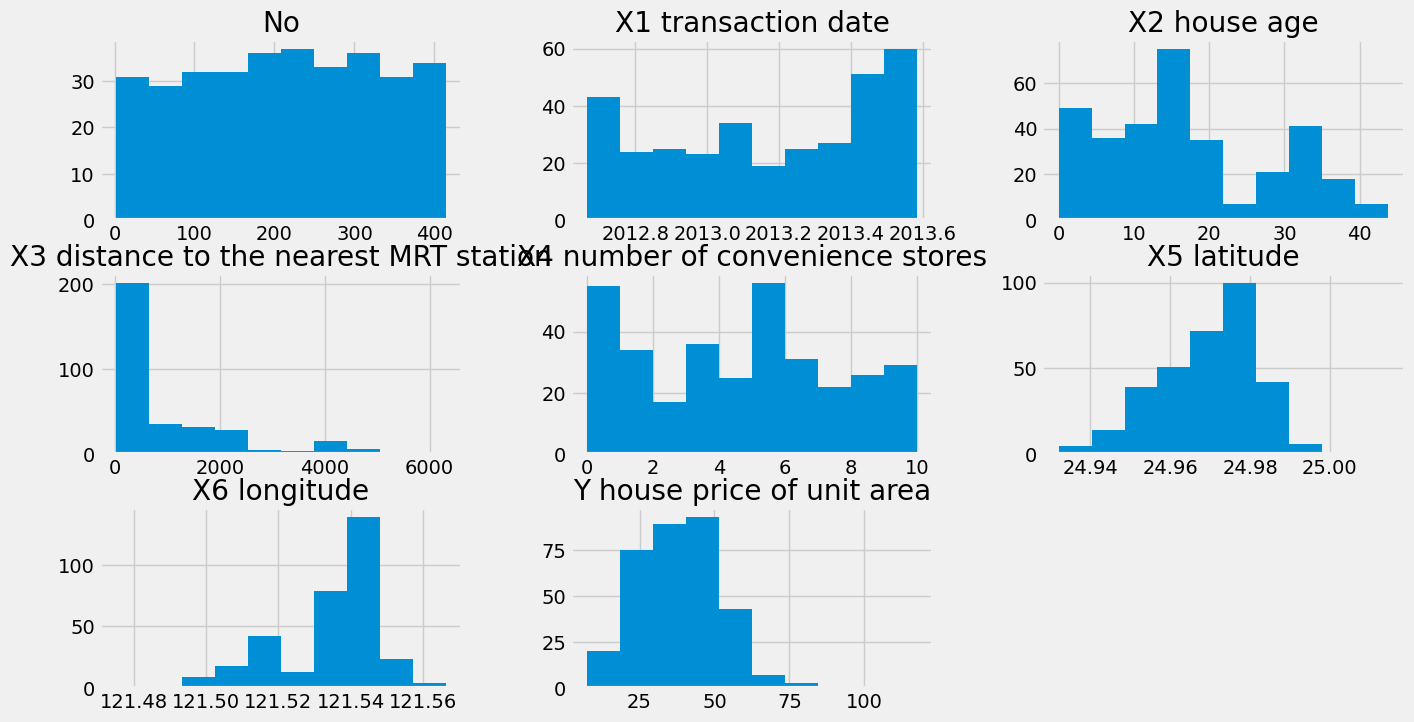

In [ ]:
train_dt.hist(figsize=(15,8))
plt.show()

<Axes: >

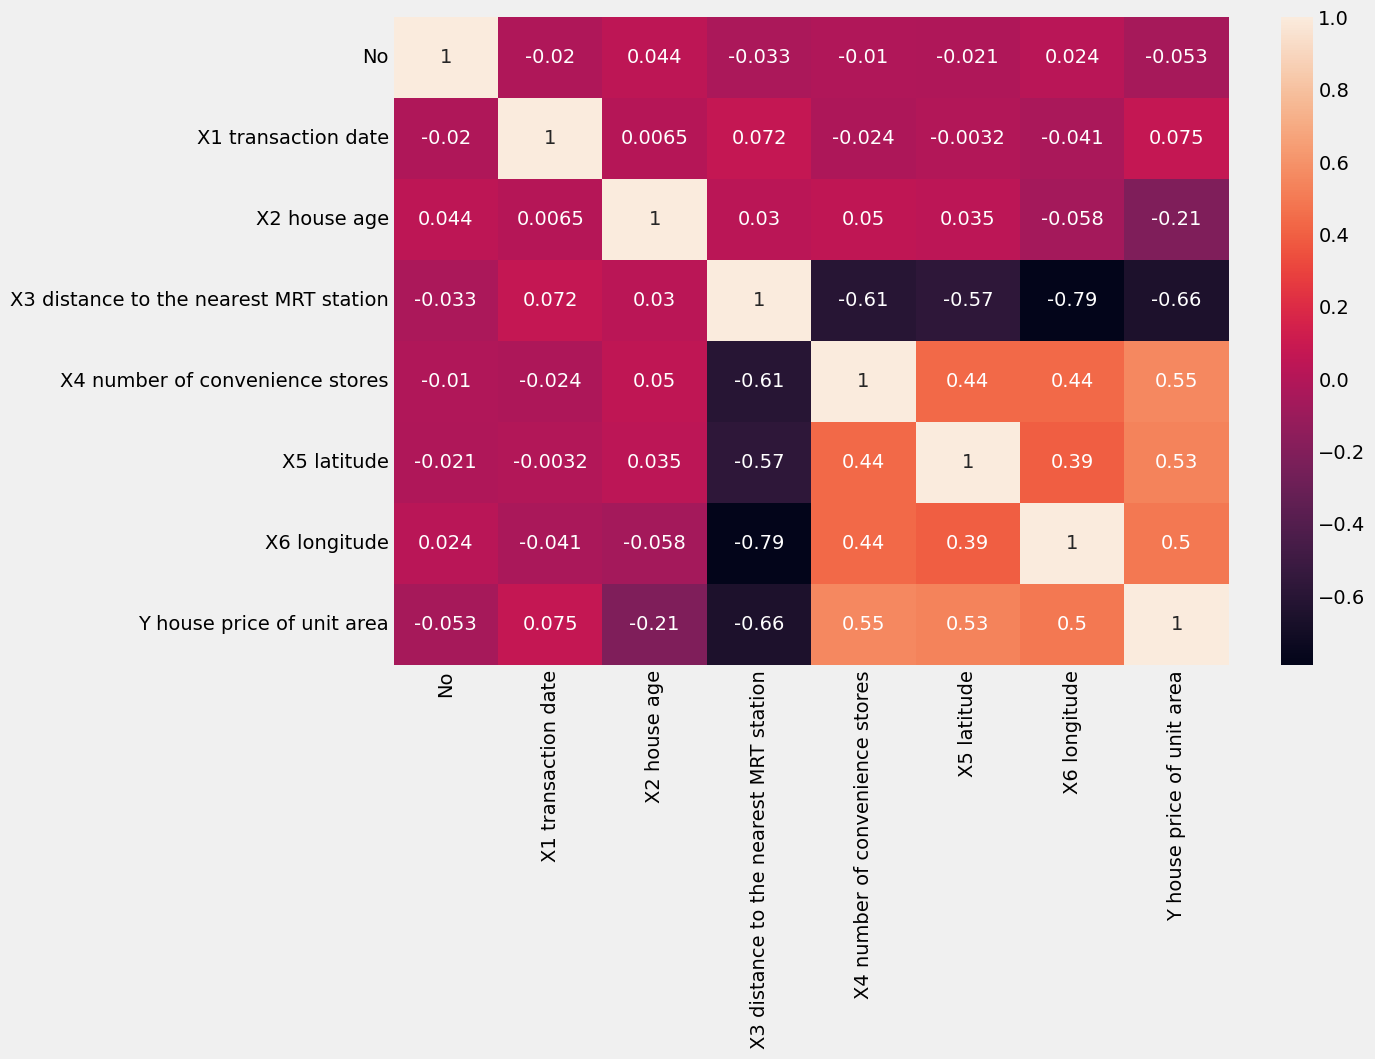

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(train_dt.corr(),annot=True)

In [ ]:
train_dt['X1 transaction date'] = np.log(train_dt['X1 transaction date'])
train_dt['X2 house age'] = np.log(train_dt['X2 house age'])
train_dt['X3 distance to the nearest MRT station'] = np.log(train_dt['X3 distance to the nearest MRT station'])
train_dt['X4 number of convenience stores'] = np.log(train_dt['X4 number of convenience stores'])

In [ ]:
train_dt

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
192,193,7.607464,3.779634,4.053339,1.945910,24.96750,121.54069,42.7
234,235,7.607506,2.079442,7.703735,1.386294,24.96007,121.51361,23.9
5,6,7.607216,1.960095,7.684798,1.098612,24.96305,121.51254,32.1
45,46,7.607423,3.600048,6.191993,2.079442,24.97015,121.54494,38.3
245,246,7.607589,2.014903,6.460874,1.609438,24.97258,121.54814,40.8
...,...,...,...,...,...,...,...,...
71,72,7.607423,3.569533,6.462622,1.098612,24.97563,121.53715,40.8
106,107,7.607423,2.844909,5.244485,2.079442,24.97707,121.54308,47.1
270,271,7.607547,2.379546,5.531737,0.000000,24.97460,121.53046,117.5
348,349,7.607298,1.526056,5.559376,1.791759,24.97585,121.54516,53.7


In [ ]:
train_dt=pd.DataFrame(data)

In [ ]:
train_dt.isna().sum()

X1 transaction date                       0
X2 house_age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [ ]:
train_dt_cleaned=train_dt.dropna()

In [ ]:
train_dt_filled=train_dt.fillna(train_dt.mean())

**HISTOGRAM**

array([[<Axes: title={'center': 'X1 transaction date'}>,
        <Axes: title={'center': 'X2 house_age'}>,
        <Axes: title={'center': 'X3 distance to the nearest MRT station'}>],
       [<Axes: title={'center': 'X4 number of convenience stores'}>,
        <Axes: title={'center': 'X5 latitude'}>,
        <Axes: title={'center': 'X6 longitude'}>],
       [<Axes: title={'center': 'Y house price of unit area'}>, <Axes: >,
        <Axes: >]], dtype=object)

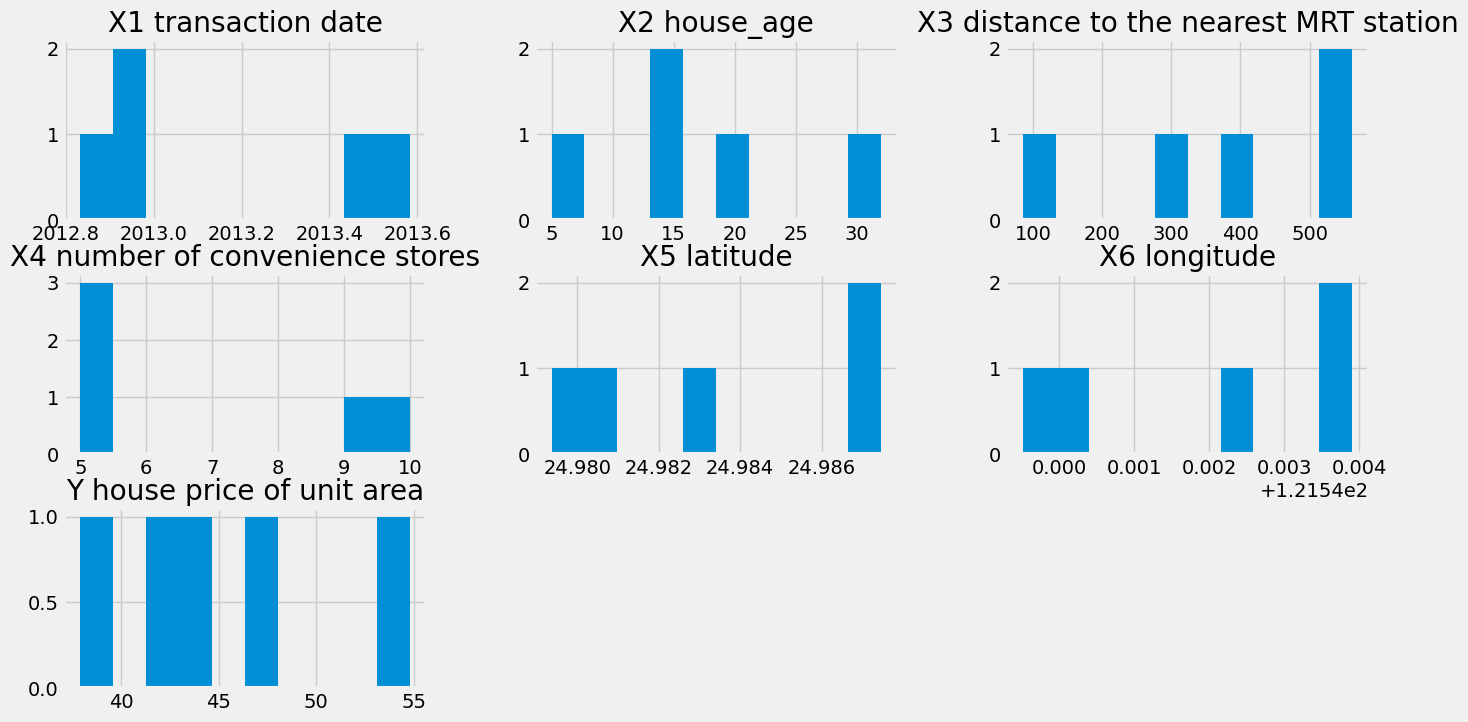

In [ ]:
train_dt_cleaned.hist(figsize=(15,8))

**HEAT MAP**

<Axes: >

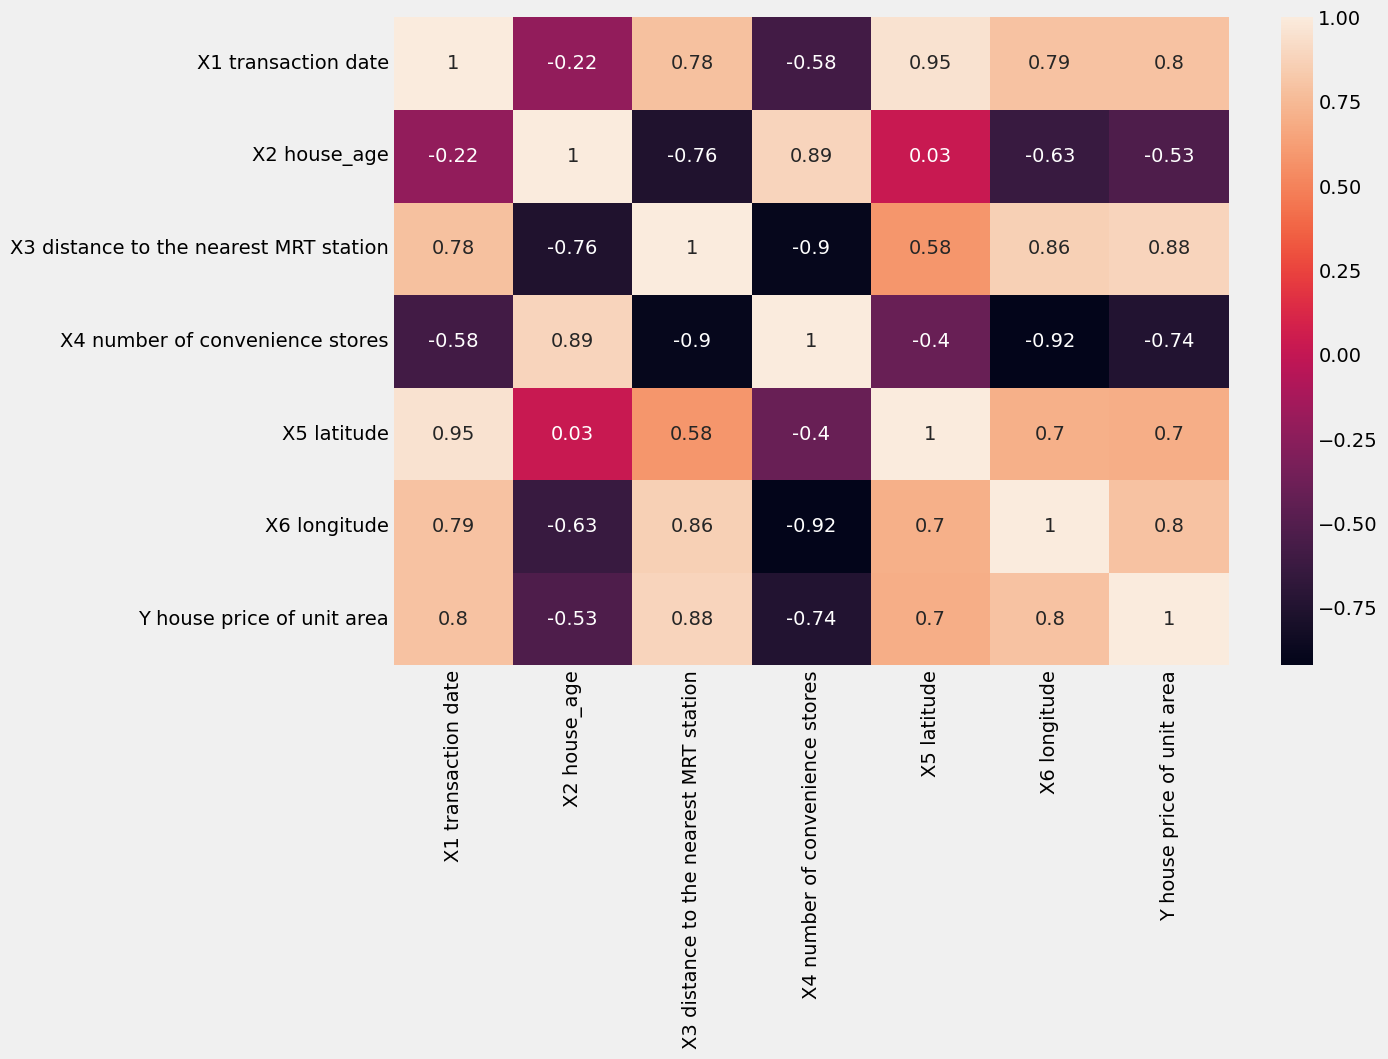

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(train_dt.corr(),annot=True)

**FEATUR MATRIX**

In [ ]:
X1_transaction_date=['2012.917','2012.917','2013.583','2013.500','2012.833']
X2_house_age=['32.0','19.5','13.3','13.3','5.0']
X3_distance_to_the_nearest_MRT_station=['84.87882','306.59470','561.98450','561.98450','390.56840']
X4_number_of_convenience_stores=['10','9','5','5','5']
X5_latitude=['24.98298','24.98034','24.98746','24.98746','24.97937']
X6_longitude=['121.54024','121.53951','121.54391','121.54391','121.54245']
dt = pd.DataFrame({
    'X1_transaction_date': X1_transaction_date,
    'X2_house_age': X2_house_age,
    'X3_distance_to_the_nearest_MRT_station': X3_distance_to_the_nearest_MRT_station,
    'X4_number_of_convenience_stores': X4_number_of_convenience_stores,
    'X5_latitude': X5_latitude,
    'X6_longitude': X6_longitude
})
numerical_features=dt[['X1_transaction_date','X2_house_age','X3_distance_to_the_nearest_MRT_station','X4_number_of_convenience_stores','X5_latitude','X6_longitude']]
X=dt.values
print("feature matrix")
print(X)

feature matrix
[['2012.917' '32.0' '84.87882' '10' '24.98298' '121.54024']
 ['2012.917' '19.5' '306.59470' '9' '24.98034' '121.53951']
 ['2013.583' '13.3' '561.98450' '5' '24.98746' '121.54391']
 ['2013.500' '13.3' '561.98450' '5' '24.98746' '121.54391']
 ['2012.833' '5.0' '390.56840' '5' '24.97937' '121.54245']]


**Z SCORE**

In [ ]:
mean=train_dt['X3 distance to the nearest MRT station'].mean()
std=train_dt['X3 distance to the nearest MRT station'].std()
z_scores=[(x-mean)/std for x in train_dt['X3 distance to the nearest MRT station']]
print(z_scores)

[-1.4870824572785777, -0.37441354316594566, 0.9072460810406845, 0.9072460810406845, 0.04700383836315336]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
scaler = StandardScaler()
x_train_s=scaler.fit_transform(x_train)
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred_lr=lr.predict(x_test)
y_pred_lr

array([47.04645871, 40.40783016, 43.37463978, 39.20600382, 26.62817953,
       45.8923956 , 44.33888897, 46.74448468, 24.43235155, 55.06258487,
       34.60848974, 36.92386329, 36.76420984, 24.30494918, 35.79519845,
       33.44810036, 44.24993318, 44.98654734, 29.18096544, 44.80711275,
        1.15259949, 36.10694406, 47.26486776, 45.90792727, 10.96198835,
       38.69069634, 12.57701679, 43.61237869, 35.7142565 , 37.55475044,
       14.14012034, 40.46209983, 35.90891223, 28.5174525 , 47.38286733,
       30.9022379 , 50.43545093, 12.92669013, 48.95222574, 39.27068588,
       39.3872837 , 40.09381011, 48.20107097, 37.08010208, 39.54765933,
       47.348201  , 43.3815801 , 21.07747224, 47.05299802, 44.57951775,
       48.24233055, 48.12297596, 41.42189435, 42.25141469, 36.32214409,
       15.69024514, 37.64733588, 35.12221291, 29.08561558, 46.86297981,
       32.07763941, 33.25961566, 15.22965501,  9.01697131,  9.37929873,
       33.78712833, 29.59931587, 47.50139803, 33.81312917, 31.84

In [ ]:
x_train,y_train=train_dt.drop('Y house price of unit area',axis=1),train_dt['Y house price of unit area']

In [ ]:
x_train=x_train.dropna()
y_train=y_train[x_train.index]

In [ ]:
from sklearn.tree import DecisionTreeRegressor
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
dtr=DecisionTreeRegressor(random_state=40)
dtr.fit(x_train,y_train)

DecisionTreeRegressor(random_state=40)

In [ ]:
y_pred=dtr.predict(x_test)

In [ ]:
y_pred

array([48.6, 31.3, 43.5, 32.9, 23.8, 48. , 42.1, 51.7, 12.8, 58.1, 27. ,
       28.4, 48. , 13.8, 34.2, 23. , 32.4, 56.8, 20.9, 34.4, 13.2, 22.9,
       46.8, 36.3, 19.2, 33.1, 12.9, 43.5, 60.7, 28.5, 18.2, 21.4, 36.8,
       26.6, 47.1, 41.4, 52.7, 12.8, 42.3, 67.7, 61.5, 37.4, 53.3, 38.1,
       42.5, 47.9, 31.6, 32.1, 45.4, 44.3, 48.6, 53.7, 34.1, 40.6, 55.3,
       11.6, 36.2, 27.3, 25.3, 51.7, 25.6, 27. , 11.6, 20.5, 24.7, 21.7,
       25.3, 31.6, 35.7, 26.6, 39.3, 48. , 57.8, 51.8, 28.5, 43.1, 39. ,
       26.9, 37.4, 31.1, 39. , 42.1, 28.4])

In [ ]:
from sklearn.ensemble import RandomForestRegressor
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rf=RandomForestRegressor(n_estimators=20,random_state=80)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=20, random_state=80)

In [ ]:
y_pred_rf=rf.predict(x_test)

In [ ]:
y_pred_rf

array([47.255, 37.77 , 57.955, 34.84 , 26.69 , 45.1  , 48.11 , 52.24 ,
       15.175, 59.87 , 25.71 , 31.125, 30.23 , 14.89 , 35.455, 24.69 ,
       38.48 , 51.065, 23.99 , 40.4  , 14.91 , 23.86 , 46.47 , 44.245,
       16.76 , 35.945, 16.45 , 63.575, 53.475, 35.   , 19.66 , 25.55 ,
       35.35 , 25.785, 50.69 , 37.465, 53.29 , 16.925, 44.545, 56.43 ,
       47.905, 40.86 , 47.795, 41.115, 39.81 , 49.115, 36.175, 24.025,
       48.05 , 44.015, 46.255, 51.565, 40.86 , 37.59 , 37.865, 15.26 ,
       37.87 , 28.02 , 25.62 , 52.38 , 27.925, 23.095, 15.595, 15.15 ,
       21.63 , 24.335, 26.13 , 42.09 , 35.155, 27.63 , 45.805, 46.75 ,
       54.79 , 53.115, 35.025, 37.545, 38.6  , 30.405, 42.08 , 31.465,
       38.01 , 48.64 , 27.78 ])

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred_lr=lr.predict(x_test)

In [ ]:
y_pred_lr

array([47.04645871, 40.40783016, 43.37463978, 39.20600382, 26.62817953,
       45.8923956 , 44.33888897, 46.74448468, 24.43235155, 55.06258487,
       34.60848974, 36.92386329, 36.76420984, 24.30494918, 35.79519845,
       33.44810036, 44.24993318, 44.98654734, 29.18096544, 44.80711275,
        1.15259949, 36.10694406, 47.26486776, 45.90792727, 10.96198835,
       38.69069634, 12.57701679, 43.61237869, 35.7142565 , 37.55475044,
       14.14012034, 40.46209983, 35.90891223, 28.5174525 , 47.38286733,
       30.9022379 , 50.43545093, 12.92669013, 48.95222574, 39.27068588,
       39.3872837 , 40.09381011, 48.20107097, 37.08010208, 39.54765933,
       47.348201  , 43.3815801 , 21.07747224, 47.05299802, 44.57951775,
       48.24233055, 48.12297596, 41.42189435, 42.25141469, 36.32214409,
       15.69024514, 37.64733588, 35.12221291, 29.08561558, 46.86297981,
       32.07763941, 33.25961566, 15.22965501,  9.01697131,  9.37929873,
       33.78712833, 29.59931587, 47.50139803, 33.81312917, 31.84

In [ ]:
import xgboost as xg
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
xg=xg.XGBRegressor(objective='reg:linear',n_estimators=50,seed=23)

In [ ]:
xg.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

In [ ]:
y_pred_xg=xg.predict(x_test)
y_pred_xg

array([47.712822, 40.52214 , 50.69717 , 34.09948 , 27.977884, 38.721985,
       46.77584 , 55.260002, 14.157741, 58.728035, 22.432505, 29.62053 ,
       39.651096, 13.704775, 33.424713, 23.793558, 40.294567, 51.232845,
       24.4869  , 38.313156, 16.004274, 22.228636, 45.46217 , 47.749302,
       16.75263 , 34.15112 , 17.960985, 47.614395, 51.880928, 34.14135 ,
       18.281977, 22.463894, 35.421288, 26.008364, 52.332703, 37.73647 ,
       52.880836, 21.129921, 39.65197 , 61.619675, 50.31563 , 39.94509 ,
       47.78348 , 36.80488 , 40.33751 , 50.594   , 31.954237, 22.16551 ,
       44.93401 , 45.870678, 48.249428, 52.57715 , 40.756714, 37.78505 ,
       40.367077, 15.325667, 40.969494, 27.39041 , 24.446331, 52.86202 ,
       24.485062, 28.371212, 15.83682 , 13.893446, 20.665623, 24.497194,
       26.36634 , 41.266865, 31.549402, 27.042875, 41.530815, 47.782513,
       55.109768, 50.7787  , 35.2485  , 39.67647 , 39.46367 , 37.684643,
       35.844147, 41.146164, 38.70123 , 45.66824 , 

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gbr=GradientBoostingRegressor(n_estimators=18,max_depth=3,learning_rate=1)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
gbr.fit(x_train,y_train)

GradientBoostingRegressor(learning_rate=1, n_estimators=18)

In [ ]:
y_pred_gbr=gbr.predict(x_test)
y_pred_gbr

array([44.23842817, 39.99724716, 46.38737157, 31.11539448, 25.76085975,
       38.73959264, 43.91634009, 54.93161459, 13.62717811, 61.40751815,
       29.31403184, 28.72032606, 37.82130374, 15.62825116, 35.67299868,
       27.51482948, 38.69211082, 56.92703302, 23.55876136, 38.85060705,
       13.95495649, 21.15786401, 50.39040742, 51.45516859, 13.94062895,
       31.00407417, 17.05176466, 50.35622293, 38.21583921, 39.85752925,
       17.67285457, 26.45610768, 30.03574438, 25.48084087, 54.08673709,
       38.63729118, 57.31199197, 20.42214524, 47.23673198, 40.71228184,
       68.91171485, 18.99277846, 52.454288  , 36.94217199, 37.58714354,
       44.54598669, 32.18051122, 20.16581561, 46.77945826, 50.24404822,
       43.64274345, 51.78509778, 42.50902159, 38.96123237, 35.38299668,
       16.22186287, 37.24780053, 33.77529266, 24.22935328, 54.93161459,
       20.53100288, 26.93996654, 18.13059736, 11.20619401, 21.27031975,
       19.80219851, 21.38711721, 39.74550023, 33.9375852 , 26.69

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

In [ ]:
adr=AdaBoostRegressor(n_estimators=10,learning_rate=1,random_state=20)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

In [ ]:
adr.fit(x_train,y_train)

AdaBoostRegressor(learning_rate=1, n_estimators=10, random_state=20)

In [ ]:
y_pred_adr=adr.predict(x_test)
y_pred_adr

array([36.23333333, 43.7253012 , 25.58676471, 39.76923077, 62.43157895,
       41.36178862, 25.90392157, 25.58676471, 25.96911765, 42.21222222,
       39.76923077, 25.90392157, 47.50869565, 45.716     , 31.45135135,
       19.4984127 , 42.21222222, 41.38363636, 39.78253968, 49.35555556,
       19.4984127 , 42.21222222, 49.35555556, 25.90392157, 41.36178862,
       19.4984127 , 25.90392157, 38.5125    , 51.47014925, 41.36178862,
       41.36178862, 36.27647059, 27.66296296, 30.84864865, 59.57      ,
       53.7375    , 53.7375    , 41.36178862, 41.36178862, 47.50869565,
       49.35555556, 25.90392157, 47.50869565, 49.35555556, 49.35555556,
       49.35555556, 53.7375    , 27.66296296, 36.27647059, 20.91445783,
       25.58676471, 45.716     , 45.716     , 47.50869565, 49.35555556,
       53.7375    , 37.36666667, 25.90392157, 36.73150685, 41.38363636,
       51.47014925, 25.90392157, 25.58676471, 38.5125    , 41.36178862,
       25.90392157, 47.50869565, 59.57      , 39.76923077, 36.27

In [ ]:
print("The accuracy of Multi linear Regression",{r2_score(y_pred_lr,y_test)})
print("The accuracy of Decision Tree Regression",{r2_score(y_pred,y_test)})
print("The accuracy of Random Forest Regression",{r2_score(y_pred_rf,y_test)})
print("The accuracy of XGBoost Regression",{r2_score(y_pred_xg,y_test)})
print("The accuracy of Gradient Boosting Regression",{r2_score(y_pred_gbr,y_test)})

The accuracy of Multi linear Regression {0.5539331260246325}
The accuracy of Decision Tree Regression {0.6647142680544441}
The accuracy of Random Forest Regression {0.7614396134445647}
The accuracy of XGBoost Regression {0.7696263036408163}
The accuracy of Gradient Boosting Regression {0.6689021609268568}


In [ ]:
import xgboost as xg
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
xg=xg.XGBRegressor(objective='reg:linear',n_estimators=50,seed=23)

In [ ]:
xg.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

In [ ]:
y_pred_xg=xg.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ac = r2_score(y_pred_xg, y_test)
rms = np.sqrt(mean_squared_error(y_pred_xg, y_test))
ms = mean_squared_error(y_pred_xg, y_test)
ac,rms,ms

(0.7696263036408163, 5.817132191159124, 33.83902692941975)

In [ ]:
import pickle
!mkdir models

with open('models/price.pkl', 'wb') as f:
    pickle.dump(xg, f) # Assuming you want to save the XGBoost model

mkdir: cannot create directory ‘models’: File exists
